# Options Greeks Calculator & Visualiser
### By: Amartiya Kakodiya | IIT Kharagpur

## Overview
This project computes and visualises all 5 Options Greeks 
(Delta, Gamma, Theta, Vega, Rho) using the Black-Scholes 
pricing model built from scratch. The project analyses how 
each Greek behaves across different stock prices, volatility 
levels and compares Call vs Put sensitivities through 
interactive plots and 3D surfaces.

## Methodology
1. Build Black-Scholes pricing formula from scratch
2. Derive all 5 Greeks analytically
3. Plot Greeks vs Stock Price (2D)
4. Plot Greeks vs Volatility (2D)
5. Plot 3D sensitivity surfaces for Delta and Gamma
6. Compare Call vs Put Greeks side by side

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")

All libraries imported successfully


## Step 1 — Black-Scholes & All 5 Greeks Functions
We implement Black-Scholes and all 5 Greeks from scratch:
- **Delta** — sensitivity of option price to stock price
- **Gamma** — rate of change of Delta
- **Theta** — time decay of option price per day
- **Vega**  — sensitivity to volatility (per 1% move)
- **Rho**   — sensitivity to interest rate (per 1% move)

In [3]:
def black_scholes(S, K, T, r, sigma, option_type="call"):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    if option_type == "call":
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    return price

def delta(S, K, T, r, sigma, option_type="call"):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    if option_type == "call":
        return norm.cdf(d1)
    else:
        return norm.cdf(d1) - 1

def gamma(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.pdf(d1) / (S * sigma * np.sqrt(T))

def theta(S, K, T, r, sigma, option_type="call"):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if option_type == "call":
        return (-(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)) 
                - r * K * np.exp(-r * T) * norm.cdf(d2)) / 365
    else:
        return (-(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)) 
                + r * K * np.exp(-r * T) * norm.cdf(-d2)) / 365

def vega(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return S * norm.pdf(d1) * np.sqrt(T) / 100

def rho(S, K, T, r, sigma, option_type="call"):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if option_type == "call":
        return K * T * np.exp(-r * T) * norm.cdf(d2) / 100
    else:
        return -K * T * np.exp(-r * T) * norm.cdf(-d2) / 100

# Test all functions
S, K, T, r, sigma = 100, 100, 1, 0.05, 0.20

print("=" * 40)
print(f"  OPTIONS GREEKS TEST (ATM Call)")
print("=" * 40)
print(f"  Price:  ${black_scholes(S,K,T,r,sigma):.4f}")
print(f"  Delta:   {delta(S,K,T,r,sigma):.4f}")
print(f"  Gamma:   {gamma(S,K,T,r,sigma):.4f}")
print(f"  Theta:   {theta(S,K,T,r,sigma):.4f}")
print(f"  Vega:    {vega(S,K,T,r,sigma):.4f}")
print(f"  Rho:     {rho(S,K,T,r,sigma):.4f}")
print("=" * 40)

  OPTIONS GREEKS TEST (ATM Call)
  Price:  $10.4506
  Delta:   0.6368
  Gamma:   0.0188
  Theta:   -0.0176
  Vega:    0.3752
  Rho:     0.5323


## Step 2 — Greeks vs Stock Price
We plot how each Greek changes as stock price moves from 
$60 to $140 with strike fixed at $100. The red dotted 
line marks the strike price (ATM point).

Key observations:
- Delta moves from 0 to 1 as stock goes deep ITM
- Gamma peaks at ATM — highest uncertainty around strike
- Theta is most negative ATM — time decay highest there

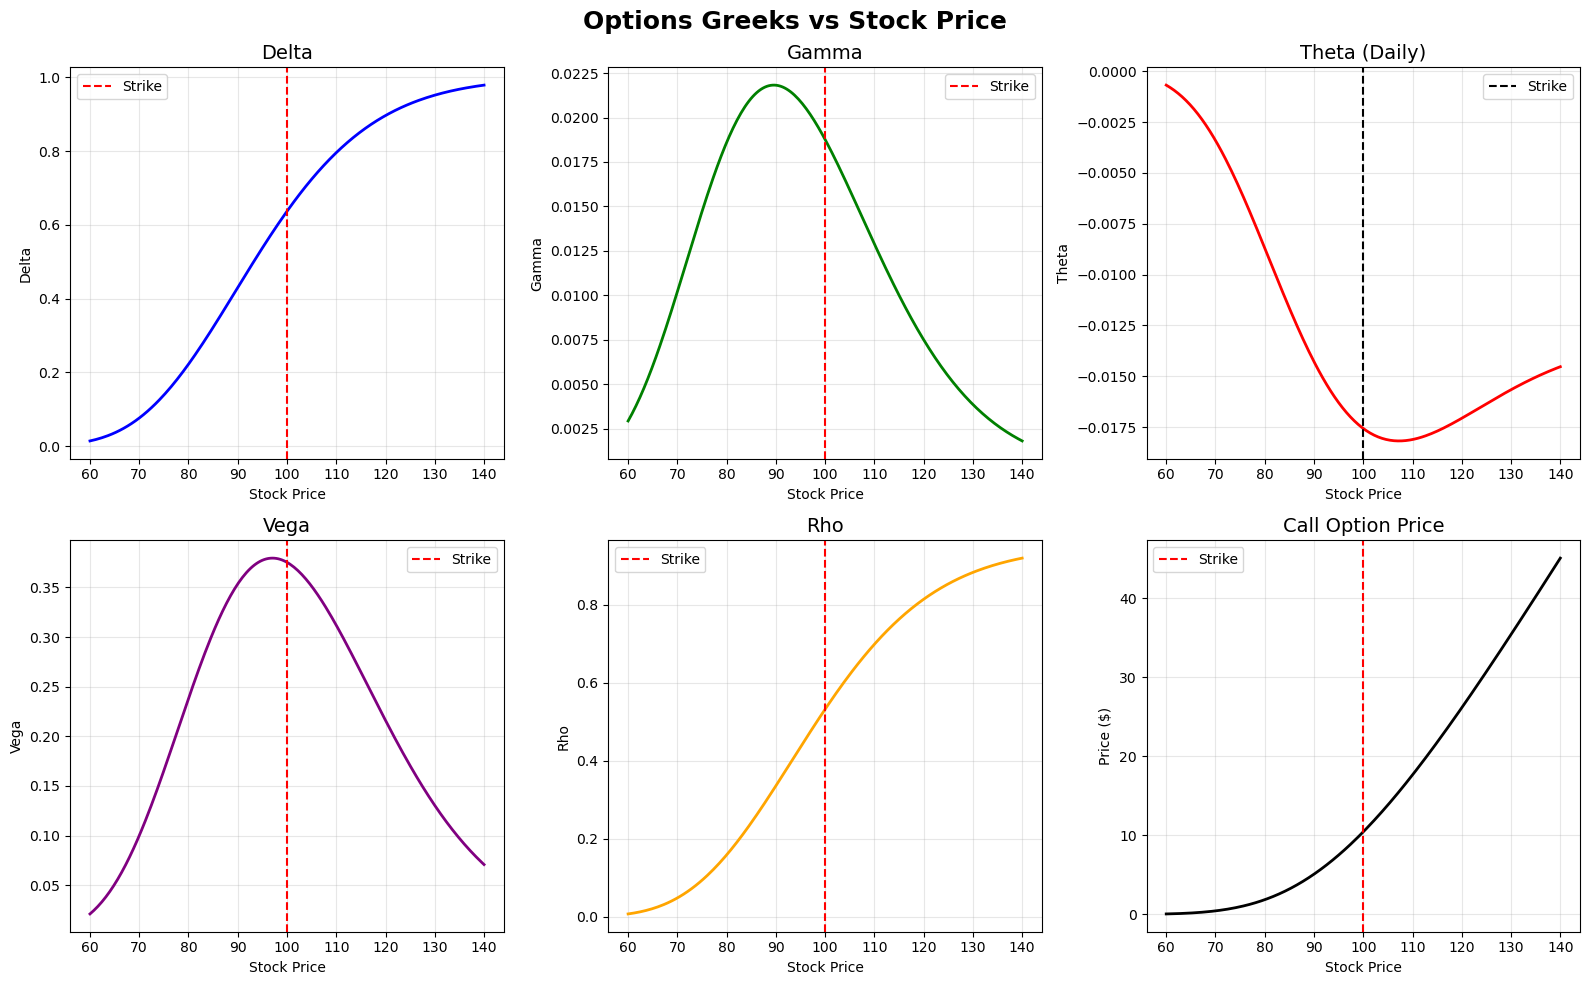

Greeks vs Stock Price plotted successfully


In [5]:
# Parameters
K     = 100
T     = 1
r     = 0.05
sigma = 0.20

# Stock price range
S_range = np.linspace(60, 140, 200)

# Compute Greeks across stock price range
deltas = [delta(S, K, T, r, sigma, "call") for S in S_range]
gammas = [gamma(S, K, T, r, sigma) for S in S_range]
thetas = [theta(S, K, T, r, sigma, "call") for S in S_range]
vegas  = [vega(S, K, T, r, sigma) for S in S_range]
rhos   = [rho(S, K, T, r, sigma, "call") for S in S_range]

# Plot
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Options Greeks vs Stock Price", fontsize=18, fontweight="bold")

# Delta
axes[0,0].plot(S_range, deltas, color="blue", linewidth=2)
axes[0,0].set_title("Delta", fontsize=14)
axes[0,0].set_xlabel("Stock Price")
axes[0,0].set_ylabel("Delta")
axes[0,0].axvline(x=K, color="red", linestyle="--", label="Strike")
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Gamma
axes[0,1].plot(S_range, gammas, color="green", linewidth=2)
axes[0,1].set_title("Gamma", fontsize=14)
axes[0,1].set_xlabel("Stock Price")
axes[0,1].set_ylabel("Gamma")
axes[0,1].axvline(x=K, color="red", linestyle="--", label="Strike")
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Theta
axes[0,2].plot(S_range, thetas, color="red", linewidth=2)
axes[0,2].set_title("Theta (Daily)", fontsize=14)
axes[0,2].set_xlabel("Stock Price")
axes[0,2].set_ylabel("Theta")
axes[0,2].axvline(x=K, color="black", linestyle="--", label="Strike")
axes[0,2].legend()
axes[0,2].grid(True, alpha=0.3)

# Vega
axes[1,0].plot(S_range, vegas, color="purple", linewidth=2)
axes[1,0].set_title("Vega", fontsize=14)
axes[1,0].set_xlabel("Stock Price")
axes[1,0].set_ylabel("Vega")
axes[1,0].axvline(x=K, color="red", linestyle="--", label="Strike")
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Rho
axes[1,1].plot(S_range, rhos, color="orange", linewidth=2)
axes[1,1].set_title("Rho", fontsize=14)
axes[1,1].set_xlabel("Stock Price")
axes[1,1].set_ylabel("Rho")
axes[1,1].axvline(x=K, color="red", linestyle="--", label="Strike")
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

# Option Price
prices = [black_scholes(S, K, T, r, sigma, "call") for S in S_range]
axes[1,2].plot(S_range, prices, color="black", linewidth=2)
axes[1,2].set_title("Call Option Price", fontsize=14)
axes[1,2].set_xlabel("Stock Price")
axes[1,2].set_ylabel("Price ($)")
axes[1,2].axvline(x=K, color="red", linestyle="--", label="Strike")
axes[1,2].legend()
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("greeks_vs_stock_price.png", dpi=150)
plt.show()
print("Greeks vs Stock Price plotted successfully")

## Step 3 — Greeks vs Volatility
We plot how each Greek changes as volatility moves from 
1% to 80% with stock price fixed at ATM ($100).

Key observations:
- Vega increases with volatility — more uncertainty = more value
- Delta converges to 0.5 at high volatility for ATM options
- Theta becomes more negative as volatility increases

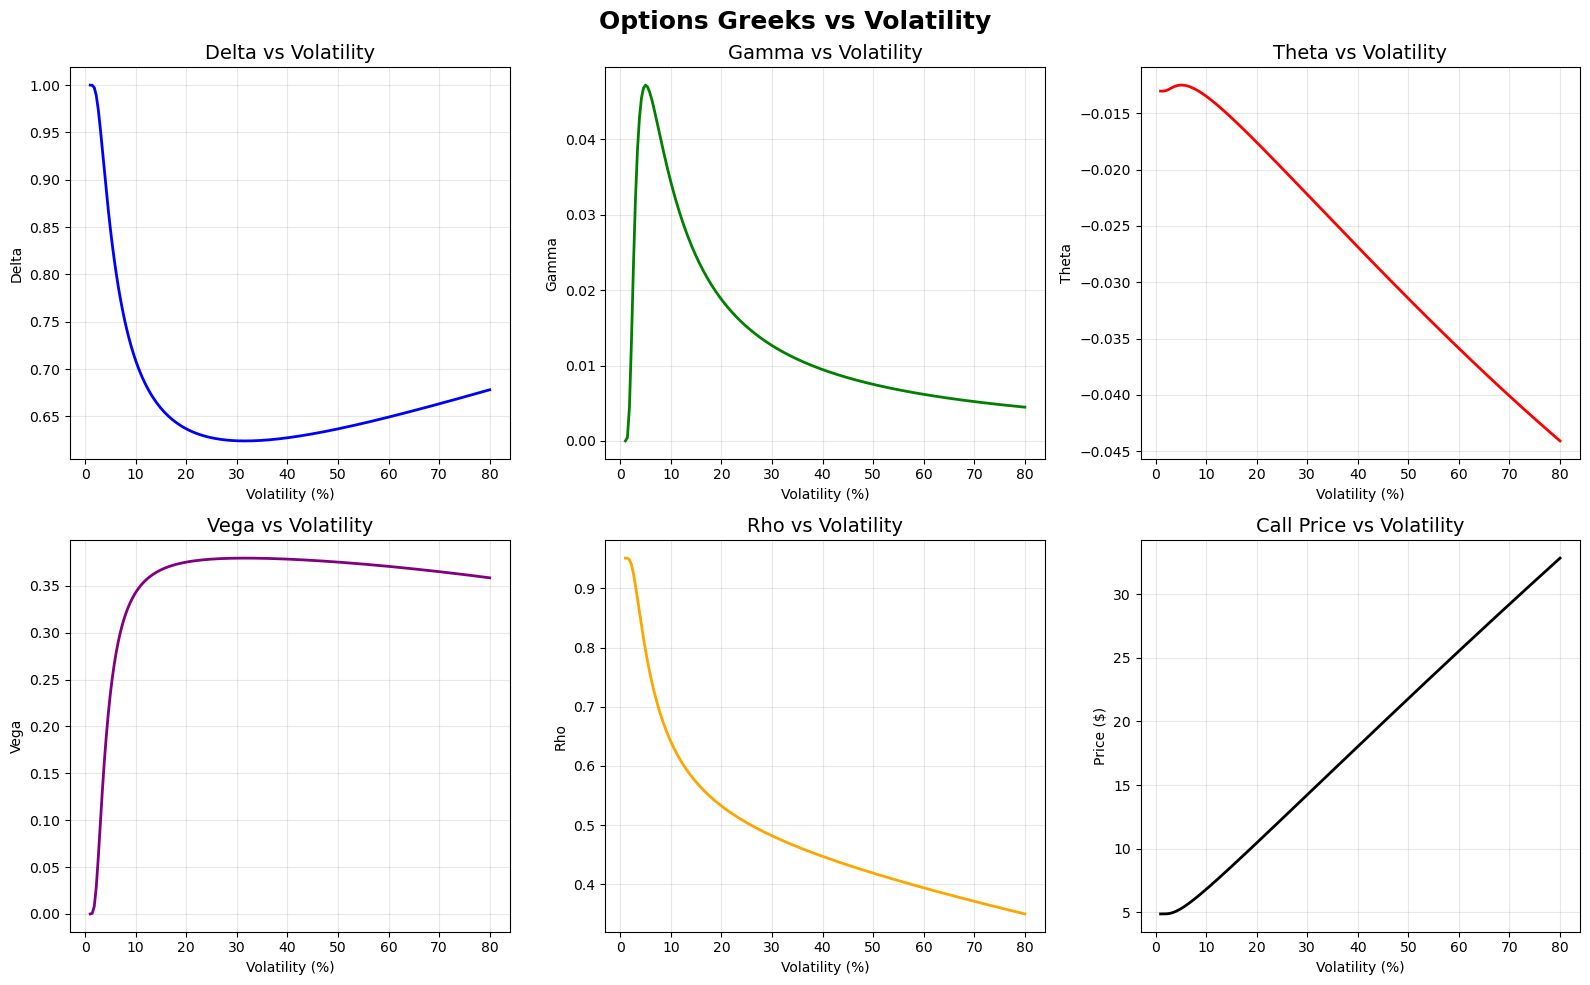

Greeks vs Volatility plotted successfully


In [7]:
# Parameters
S     = 100
K     = 100
T     = 1
r     = 0.05

# Volatility range
sigma_range = np.linspace(0.01, 0.80, 200)

# Compute Greeks across volatility range
deltas = [delta(S, K, T, r, sig, "call") for sig in sigma_range]
gammas = [gamma(S, K, T, r, sig) for sig in sigma_range]
thetas = [theta(S, K, T, r, sig, "call") for sig in sigma_range]
vegas  = [vega(S, K, T, r, sig) for sig in sigma_range]
rhos   = [rho(S, K, T, r, sig, "call") for sig in sigma_range]
prices = [black_scholes(S, K, T, r, sig, "call") for sig in sigma_range]

# Plot
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Options Greeks vs Volatility", fontsize=18, fontweight="bold")

# Delta
axes[0,0].plot(sigma_range*100, deltas, color="blue", linewidth=2)
axes[0,0].set_title("Delta vs Volatility", fontsize=14)
axes[0,0].set_xlabel("Volatility (%)")
axes[0,0].set_ylabel("Delta")
axes[0,0].grid(True, alpha=0.3)

# Gamma
axes[0,1].plot(sigma_range*100, gammas, color="green", linewidth=2)
axes[0,1].set_title("Gamma vs Volatility", fontsize=14)
axes[0,1].set_xlabel("Volatility (%)")
axes[0,1].set_ylabel("Gamma")
axes[0,1].grid(True, alpha=0.3)

# Theta
axes[0,2].plot(sigma_range*100, thetas, color="red", linewidth=2)
axes[0,2].set_title("Theta vs Volatility", fontsize=14)
axes[0,2].set_xlabel("Volatility (%)")
axes[0,2].set_ylabel("Theta")
axes[0,2].grid(True, alpha=0.3)

# Vega
axes[1,0].plot(sigma_range*100, vegas, color="purple", linewidth=2)
axes[1,0].set_title("Vega vs Volatility", fontsize=14)
axes[1,0].set_xlabel("Volatility (%)")
axes[1,0].set_ylabel("Vega")
axes[1,0].grid(True, alpha=0.3)

# Rho
axes[1,1].plot(sigma_range*100, rhos, color="orange", linewidth=2)
axes[1,1].set_title("Rho vs Volatility", fontsize=14)
axes[1,1].set_xlabel("Volatility (%)")
axes[1,1].set_ylabel("Rho")
axes[1,1].grid(True, alpha=0.3)

# Option Price
axes[1,2].plot(sigma_range*100, prices, color="black", linewidth=2)
axes[1,2].set_title("Call Price vs Volatility", fontsize=14)
axes[1,2].set_xlabel("Volatility (%)")
axes[1,2].set_ylabel("Price ($)")
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("greeks_vs_volatility.png", dpi=150)
plt.show()
print("Greeks vs Volatility plotted successfully")

## Step 4 — 3D Sensitivity Surfaces
We build 3D surfaces showing how Delta and Gamma vary 
simultaneously across both Stock Price and Volatility.
This gives a complete picture of option sensitivity 
across all market conditions — similar to what quant 
desks use for risk management and hedging decisions.

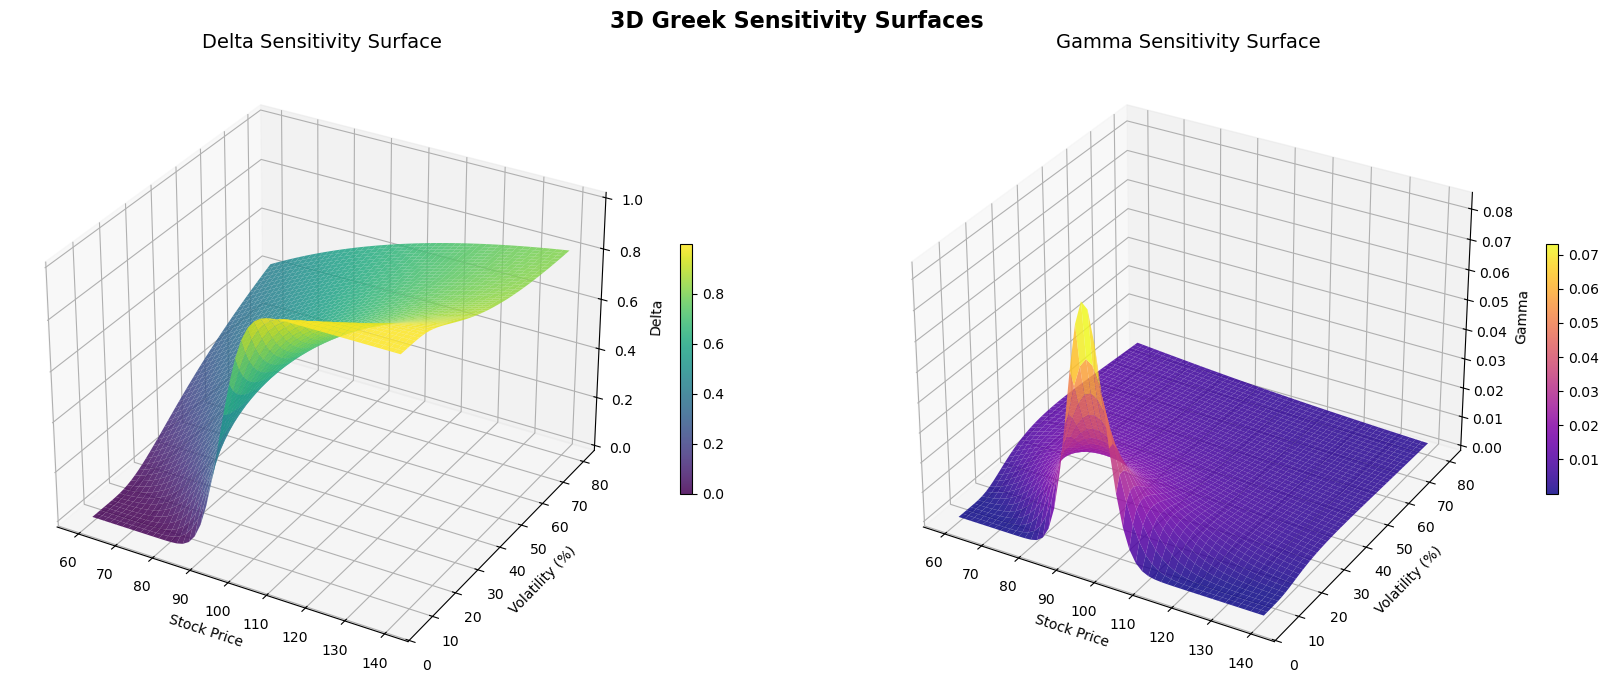

3D Sensitivity Surfaces plotted successfully


In [9]:
from mpl_toolkits.mplot3d import Axes3D

# Parameters
K = 100
T = 1
r = 0.05

# Ranges
S_range     = np.linspace(60, 140, 50)
sigma_range = np.linspace(0.05, 0.80, 50)
S_grid, sigma_grid = np.meshgrid(S_range, sigma_range)

# Compute Delta and Gamma on grid
delta_grid = np.vectorize(lambda S, sig: delta(S, K, T, r, sig, "call"))(S_grid, sigma_grid)
gamma_grid = np.vectorize(lambda S, sig: gamma(S, K, T, r, sig))(S_grid, sigma_grid)

# Plot
fig = plt.figure(figsize=(18, 7))

# Delta Surface
ax1 = fig.add_subplot(121, projection="3d")
surf1 = ax1.plot_surface(S_grid, sigma_grid*100, delta_grid, 
                          cmap="viridis", alpha=0.85)
ax1.set_title("Delta Sensitivity Surface", fontsize=14)
ax1.set_xlabel("Stock Price")
ax1.set_ylabel("Volatility (%)")
ax1.set_zlabel("Delta")
fig.colorbar(surf1, ax=ax1, shrink=0.4)

# Gamma Surface
ax2 = fig.add_subplot(122, projection="3d")
surf2 = ax2.plot_surface(S_grid, sigma_grid*100, gamma_grid,
                          cmap="plasma", alpha=0.85)
ax2.set_title("Gamma Sensitivity Surface", fontsize=14)
ax2.set_xlabel("Stock Price")
ax2.set_ylabel("Volatility (%)")
ax2.set_zlabel("Gamma")
fig.colorbar(surf2, ax=ax2, shrink=0.4)

plt.suptitle("3D Greek Sensitivity Surfaces", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("greeks_3d_surface.png", dpi=150)
plt.show()
print("3D Sensitivity Surfaces plotted successfully")

## Step 5 — Call vs Put Greeks Comparison
We compare how Greeks differ between Call and Put options.

Key relationships:
- Put-Call Parity: Call Delta - Put Delta = 1
- Gamma and Vega are identical for calls and puts
- Theta is negative for both — both lose value over time
- Rho is positive for calls, negative for puts

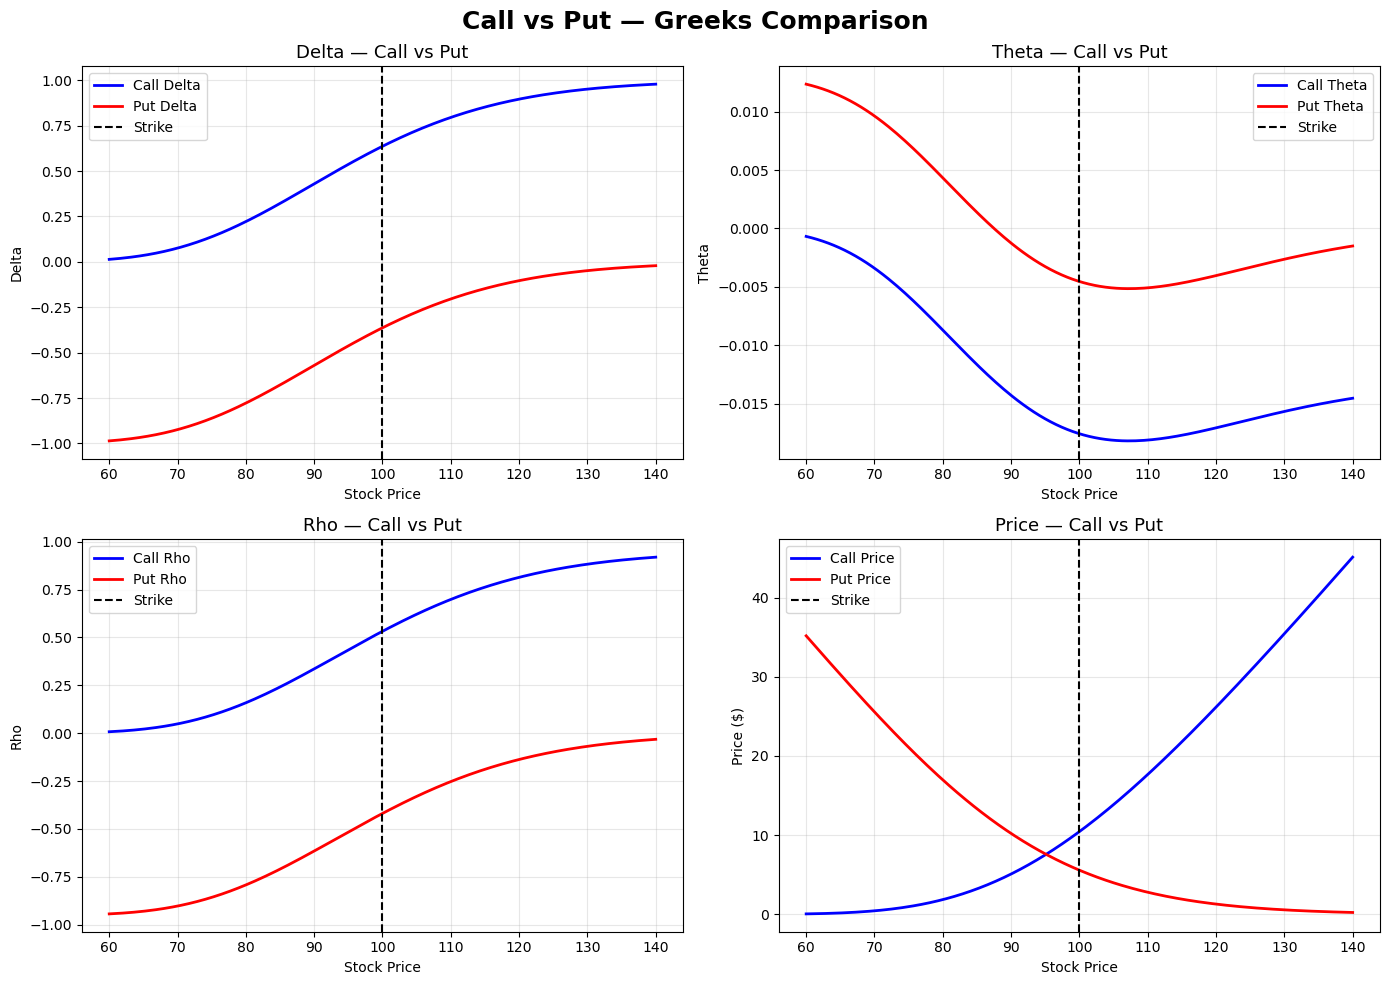

Call vs Put comparison plotted successfully


In [11]:
# Parameters
S     = 100
K     = 100
T     = 1
r     = 0.05
sigma = 0.20

# Stock price range
S_range = np.linspace(60, 140, 200)

# Compute for both call and put
call_deltas = [delta(S, K, T, r, sigma, "call") for S in S_range]
put_deltas  = [delta(S, K, T, r, sigma, "put") for S in S_range]
call_thetas = [theta(S, K, T, r, sigma, "call") for S in S_range]
put_thetas  = [theta(S, K, T, r, sigma, "put") for S in S_range]
call_rhos   = [rho(S, K, T, r, sigma, "call") for S in S_range]
put_rhos    = [rho(S, K, T, r, sigma, "put") for S in S_range]
call_prices = [black_scholes(S, K, T, r, sigma, "call") for S in S_range]
put_prices  = [black_scholes(S, K, T, r, sigma, "put") for S in S_range]

# Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Call vs Put — Greeks Comparison", fontsize=18, fontweight="bold")

# Delta
axes[0,0].plot(S_range, call_deltas, color="blue", linewidth=2, label="Call Delta")
axes[0,0].plot(S_range, put_deltas, color="red", linewidth=2, label="Put Delta")
axes[0,0].axvline(x=K, color="black", linestyle="--", label="Strike")
axes[0,0].set_title("Delta — Call vs Put", fontsize=13)
axes[0,0].set_xlabel("Stock Price")
axes[0,0].set_ylabel("Delta")
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Theta
axes[0,1].plot(S_range, call_thetas, color="blue", linewidth=2, label="Call Theta")
axes[0,1].plot(S_range, put_thetas, color="red", linewidth=2, label="Put Theta")
axes[0,1].axvline(x=K, color="black", linestyle="--", label="Strike")
axes[0,1].set_title("Theta — Call vs Put", fontsize=13)
axes[0,1].set_xlabel("Stock Price")
axes[0,1].set_ylabel("Theta")
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Rho
axes[1,0].plot(S_range, call_rhos, color="blue", linewidth=2, label="Call Rho")
axes[1,0].plot(S_range, put_rhos, color="red", linewidth=2, label="Put Rho")
axes[1,0].axvline(x=K, color="black", linestyle="--", label="Strike")
axes[1,0].set_title("Rho — Call vs Put", fontsize=13)
axes[1,0].set_xlabel("Stock Price")
axes[1,0].set_ylabel("Rho")
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Price
axes[1,1].plot(S_range, call_prices, color="blue", linewidth=2, label="Call Price")
axes[1,1].plot(S_range, put_prices, color="red", linewidth=2, label="Put Price")
axes[1,1].axvline(x=K, color="black", linestyle="--", label="Strike")
axes[1,1].set_title("Price — Call vs Put", fontsize=13)
axes[1,1].set_xlabel("Stock Price")
axes[1,1].set_ylabel("Price ($)")
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("call_vs_put.png", dpi=150)
plt.show()
print("Call vs Put comparison plotted successfully")

## Summary & Results
Complete Greeks analysis for ATM option (S=K=$100):
- Volatility: 20% | Time: 1 year | Rate: 5%
- All Greeks computed analytically from Black-Scholes
- 4 visualisations generated covering all sensitivities

In [13]:
# Parameters
S     = 100
K     = 100
T     = 1
r     = 0.05
sigma = 0.20

print("=" * 55)
print("   OPTIONS GREEKS DASHBOARD — FULL SUMMARY")
print("=" * 55)
print(f"  Underlying Price (S):      ${S}")
print(f"  Strike Price (K):          ${K}")
print(f"  Time to Expiry (T):        {T} year")
print(f"  Risk Free Rate (r):        {r*100}%")
print(f"  Volatility (sigma):        {sigma*100}%")
print("=" * 55)
print("  CALL OPTION")
print(f"  Price:    ${black_scholes(S,K,T,r,sigma,'call'):.4f}")
print(f"  Delta:     {delta(S,K,T,r,sigma,'call'):.4f}  → moves $0.64 per $1 move in S")
print(f"  Gamma:     {gamma(S,K,T,r,sigma):.4f}  → rate of change of Delta")
print(f"  Theta:     {theta(S,K,T,r,sigma,'call'):.4f}  → loses ${abs(theta(S,K,T,r,sigma,'call')):.4f} per day")
print(f"  Vega:      {vega(S,K,T,r,sigma):.4f}  → gains ${vega(S,K,T,r,sigma):.4f} per 1% IV move")
print(f"  Rho:       {rho(S,K,T,r,sigma,'call'):.4f}  → gains ${rho(S,K,T,r,sigma,'call'):.4f} per 1% rate move")
print("=" * 55)
print("  PUT OPTION")
print(f"  Price:    ${black_scholes(S,K,T,r,sigma,'put'):.4f}")
print(f"  Delta:     {delta(S,K,T,r,sigma,'put'):.4f}  → moves ${abs(delta(S,K,T,r,sigma,'put')):.4f} per $1 move in S")
print(f"  Gamma:     {gamma(S,K,T,r,sigma):.4f}  → same as call (always positive)")
print(f"  Theta:     {theta(S,K,T,r,sigma,'put'):.4f}  → loses ${abs(theta(S,K,T,r,sigma,'put')):.4f} per day")
print(f"  Vega:      {vega(S,K,T,r,sigma):.4f}  → same as call (always positive)")
print(f"  Rho:       {rho(S,K,T,r,sigma,'put'):.4f}  → loses ${abs(rho(S,K,T,r,sigma,'put')):.4f} per 1% rate move")
print("=" * 55)
print("  Plots saved:")
print("  greeks_vs_stock_price.png")
print("  greeks_vs_volatility.png")
print("  greeks_3d_surface.png")
print("  call_vs_put.png")
print("=" * 55)

   OPTIONS GREEKS DASHBOARD — FULL SUMMARY
  Underlying Price (S):      $100
  Strike Price (K):          $100
  Time to Expiry (T):        1 year
  Risk Free Rate (r):        5.0%
  Volatility (sigma):        20.0%
  CALL OPTION
  Price:    $10.4506
  Delta:     0.6368  → moves $0.64 per $1 move in S
  Gamma:     0.0188  → rate of change of Delta
  Theta:     -0.0176  → loses $0.0176 per day
  Vega:      0.3752  → gains $0.3752 per 1% IV move
  Rho:       0.5323  → gains $0.5323 per 1% rate move
  PUT OPTION
  Price:    $5.5735
  Delta:     -0.3632  → moves $0.3632 per $1 move in S
  Gamma:     0.0188  → same as call (always positive)
  Theta:     -0.0045  → loses $0.0045 per day
  Vega:      0.3752  → same as call (always positive)
  Rho:       -0.4189  → loses $0.4189 per 1% rate move
  Plots saved:
  greeks_vs_stock_price.png
  greeks_vs_volatility.png
  greeks_3d_surface.png
  call_vs_put.png
